# K-Means Clustering

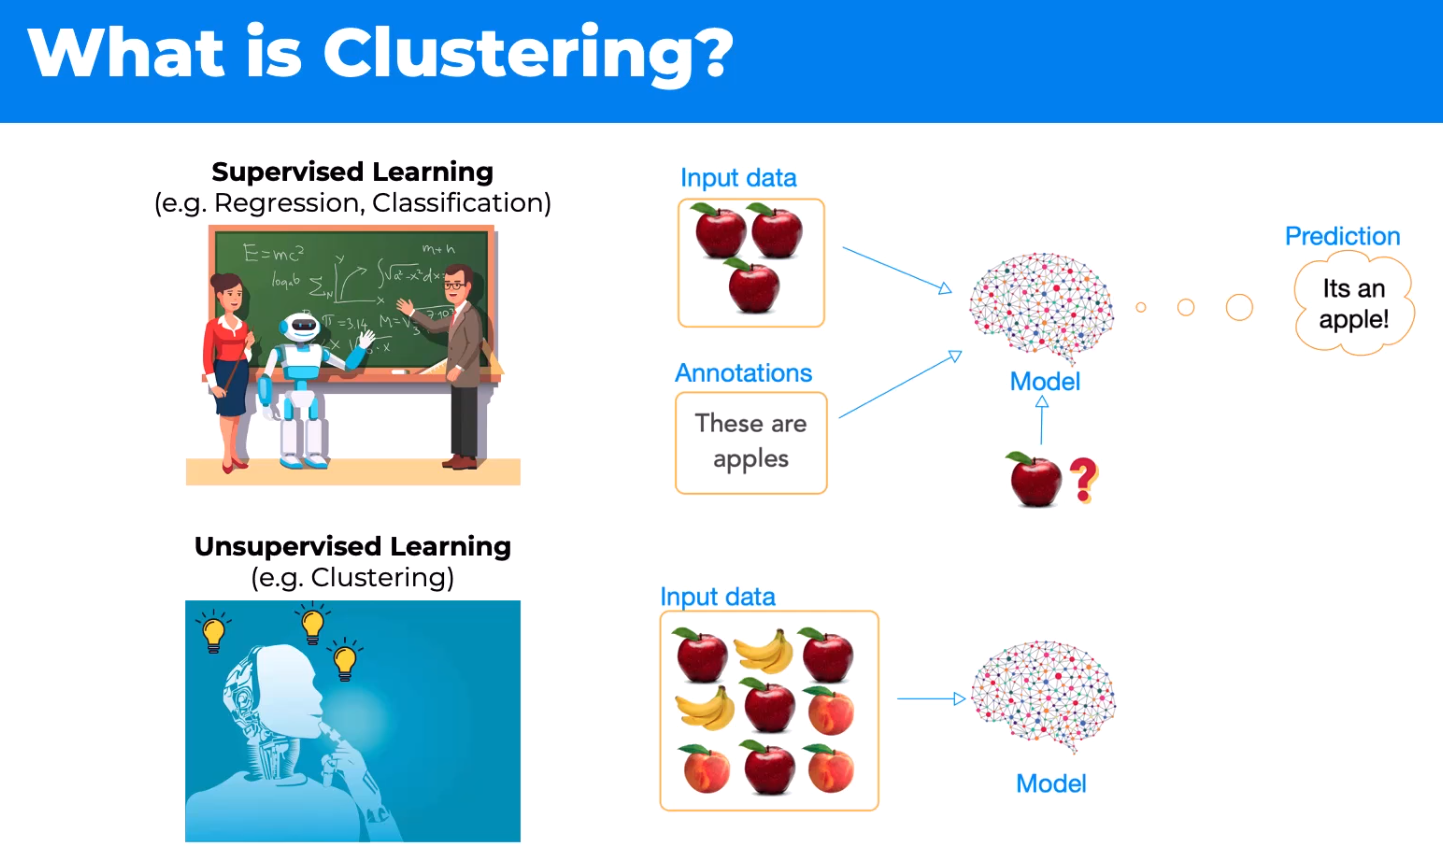

## Importing the libraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

## Importing the dataset

In [ ]:
!wget -O 'Mall_Customers.csv' 'https://drive.google.com/uc?export=download&id=1yOEBKhtcYqR8a-7CLLaU68e4wsYimYAP'

--2025-11-10 12:53:42--  https://drive.google.com/uc?export=download&id=1yOEBKhtcYqR8a-7CLLaU68e4wsYimYAP
Resolving drive.google.com (drive.google.com)... 74.125.196.100, 74.125.196.101, 74.125.196.102, ...
Connecting to drive.google.com (drive.google.com)|74.125.196.100|:443... connected.
HTTP request sent, awaiting response... 303 See Other
Location: https://drive.usercontent.google.com/download?id=1yOEBKhtcYqR8a-7CLLaU68e4wsYimYAP&export=download [following]
--2025-11-10 12:53:42--  https://drive.usercontent.google.com/download?id=1yOEBKhtcYqR8a-7CLLaU68e4wsYimYAP&export=download
Resolving drive.usercontent.google.com (drive.usercontent.google.com)... 108.177.12.132, 2607:f8b0:400c:c08::84
Connecting to drive.usercontent.google.com (drive.usercontent.google.com)|108.177.12.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4286 (4.2K) [application/octet-stream]
Saving to: ‘Mall_Customers.csv’

Mall_Customers.csv  100%[===================>]   4.19K  --.-KB/

In [ ]:
dataset = pd.read_csv('Mall_Customers.csv')
X = dataset.iloc[:, [3, 4]].values

X[:5]
dataset

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
...,...,...,...,...,...
195,196,Female,35,120,79
196,197,Female,45,126,28
197,198,Male,32,126,74
198,199,Male,32,137,18


In [ ]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X = sc.fit_transform(X)

## Using the elbow method to find the optimal number of clusters


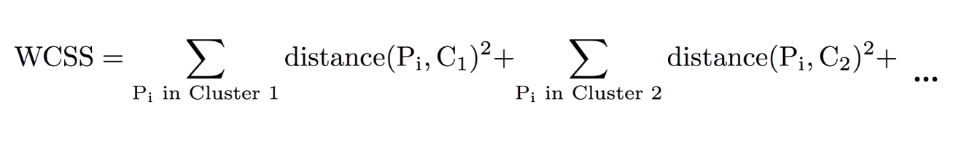

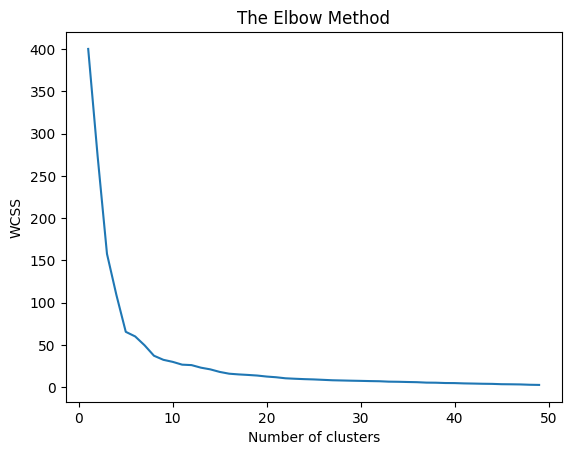

In [ ]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 50):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(X)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 50), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K-Means model on the dataset

In [ ]:
kmeans = KMeans(n_clusters = 5, init = 'k-means++', random_state = 42)
y_kmeans = kmeans.fit_predict(X)

In [ ]:
y_kmeans

array([4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2,
       4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 0,
       4, 2, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [ ]:
X[y_kmeans == 0, 0]

array([-0.82293289, -0.78476346, -0.78476346, -0.78476346, -0.78476346,
       -0.70842461, -0.70842461, -0.67025518, -0.67025518, -0.67025518,
       -0.67025518, -0.63208575, -0.63208575, -0.55574689, -0.55574689,
       -0.55574689, -0.55574689, -0.51757746, -0.51757746, -0.47940803,
       -0.47940803, -0.47940803, -0.47940803, -0.47940803, -0.47940803,
       -0.4412386 , -0.4412386 , -0.40306917, -0.40306917, -0.25039146,
       -0.25039146, -0.25039146, -0.25039146, -0.25039146, -0.25039146,
       -0.25039146, -0.25039146, -0.25039146, -0.25039146, -0.25039146,
       -0.25039146, -0.13588317, -0.13588317, -0.09771374, -0.09771374,
       -0.05954431, -0.05954431, -0.02137488, -0.02137488, -0.02137488,
       -0.02137488, -0.02137488, -0.02137488,  0.01679455,  0.01679455,
        0.05496398,  0.05496398,  0.05496398,  0.05496398,  0.05496398,
        0.05496398,  0.09313341,  0.09313341,  0.09313341,  0.09313341,
        0.09313341,  0.09313341,  0.13130284,  0.13130284,  0.16

## Visualising the clusters

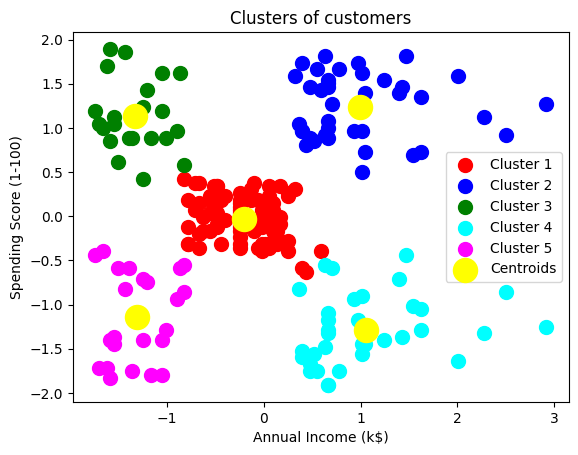

In [ ]:
plt.scatter(X[y_kmeans == 0, 0], X[y_kmeans == 0, 1], s = 100, c = 'red', label = 'Cluster 1')
plt.scatter(X[y_kmeans == 1, 0], X[y_kmeans == 1, 1], s = 100, c = 'blue', label = 'Cluster 2')
plt.scatter(X[y_kmeans == 2, 0], X[y_kmeans == 2, 1], s = 100, c = 'green', label = 'Cluster 3')
plt.scatter(X[y_kmeans == 3, 0], X[y_kmeans == 3, 1], s = 100, c = 'cyan', label = 'Cluster 4')
plt.scatter(X[y_kmeans == 4, 0], X[y_kmeans == 4, 1], s = 100, c = 'magenta', label = 'Cluster 5')
plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], s = 300, c = 'yellow', label = 'Centroids')
plt.title('Clusters of customers')
plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

# Drawbacks


Kmeans algorithm is good in capturing structure of the data if clusters have a spherical-like shape. It always try to construct a nice spherical shape around the centroid. That means, the minute the clusters have a complicated geometric shapes, kmeans does a poor job in clustering the data.

## Example 1

We would have 3 groups of data where each group was generated from different multivariate normal distribution (different mean/standard deviation). One group will have a lot more data points than the other two combined.

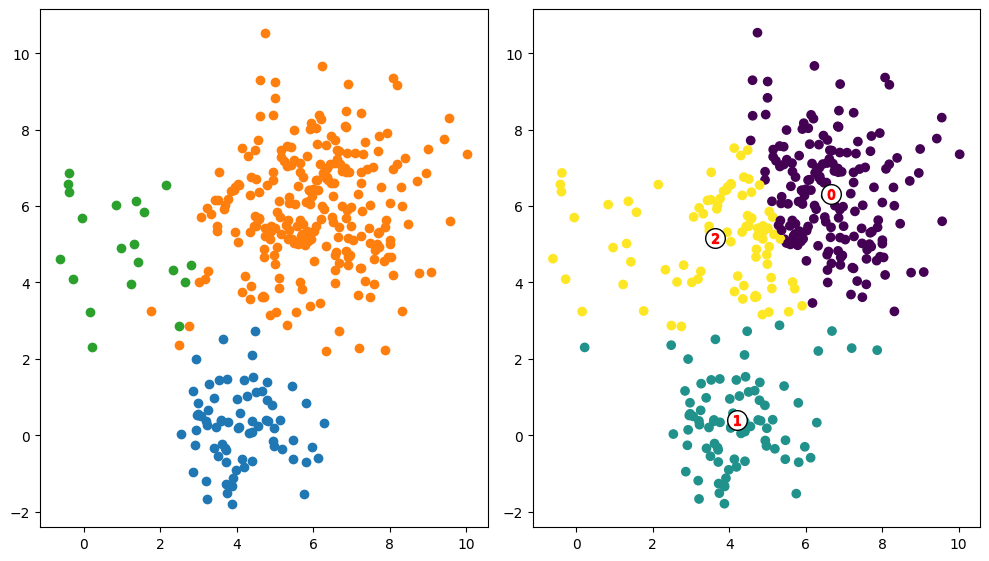

In [ ]:
# Create data from three different multivariate distributions
X_1 = np.random.multivariate_normal(mean=[4, 0], cov=[[1, 0], [0, 1]], size=75)
X_2 = np.random.multivariate_normal(mean=[6, 6], cov=[[2, 0], [0, 2]], size=250)
X_3 = np.random.multivariate_normal(mean=[1, 5], cov=[[1, 0], [0, 2]], size=20)
df = np.concatenate([X_1, X_2, X_3])

# Run kmeans
km = KMeans(n_clusters=3)
km.fit(df)
labels = km.predict(df)
centroids = km.cluster_centers_

# Plot the data
fig, ax = plt.subplots(1, 2, figsize=(10, 10))
ax[0].scatter(X_1[:, 0], X_1[:, 1])
ax[0].scatter(X_2[:, 0], X_2[:, 1])
ax[0].scatter(X_3[:, 0], X_3[:, 1])
ax[0].set_aspect('equal')
ax[1].scatter(df[:, 0], df[:, 1], c=labels)
ax[1].scatter(centroids[:, 0], centroids[:, 1], marker='o',
                c="white", alpha=1, s=200, edgecolor='k')
for i, c in enumerate(centroids):
    ax[1].scatter(c[0], c[1], marker='$%d$' % i, s=50, alpha=1, edgecolor='r')
ax[1].set_aspect('equal')
plt.tight_layout()

# Example 2



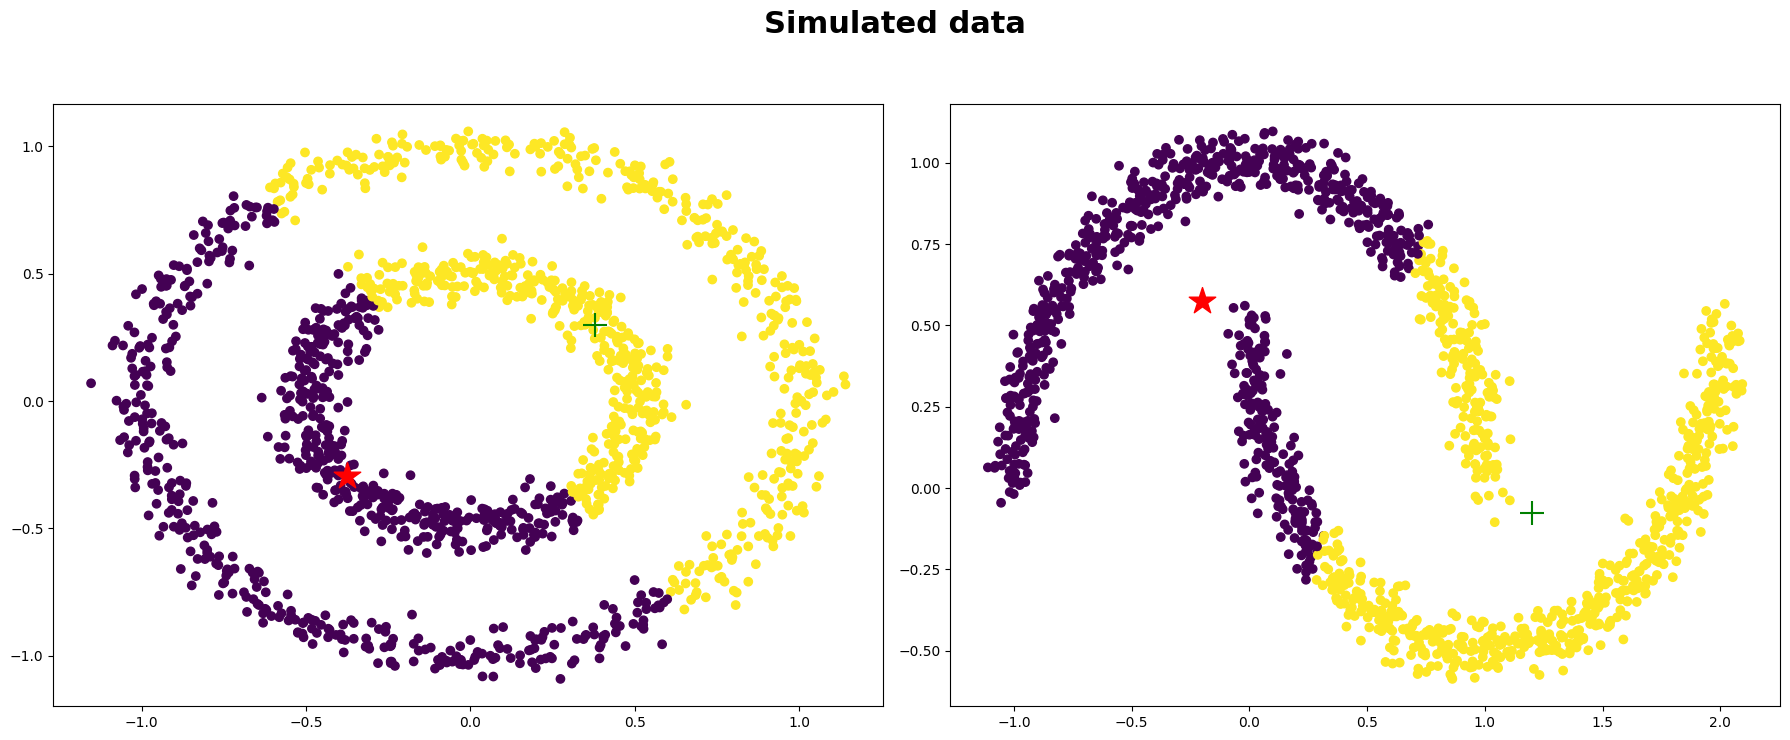

In [ ]:
from sklearn.datasets import make_blobs, make_circles, make_moons


# Cricles
X1 = make_circles(factor=0.5, noise=0.05, n_samples=1500)

# Moons
X2 = make_moons(n_samples=1500, noise=0.05)

fig, ax = plt.subplots(1, 2)
for i, X in enumerate([X1, X2]):
    fig.set_size_inches(18, 7)
    km = KMeans(n_clusters=2)
    km.fit(X[0])
    labels = km.predict(X[0])
    centroids = km.cluster_centers_
    ax[i].scatter(X[0][:, 0], X[0][:, 1], c=labels)
    ax[i].scatter(centroids[0, 0], centroids[0, 1], marker='*', s=400, c='r')
    ax[i].scatter(centroids[1, 0], centroids[1, 1], marker='+', s=300, c='green')

plt.suptitle('Simulated data', y=1.05, fontsize=22, fontweight='semibold')
plt.tight_layout()

As expected, kmeans couldn’t figure out the correct clusters for both datasets. However, we can help kmeans perfectly cluster these kind of datasets if we use kernel methods. The idea is we transform to higher dimensional representation that make the data linearly separable (the same idea that we use in SVMs)

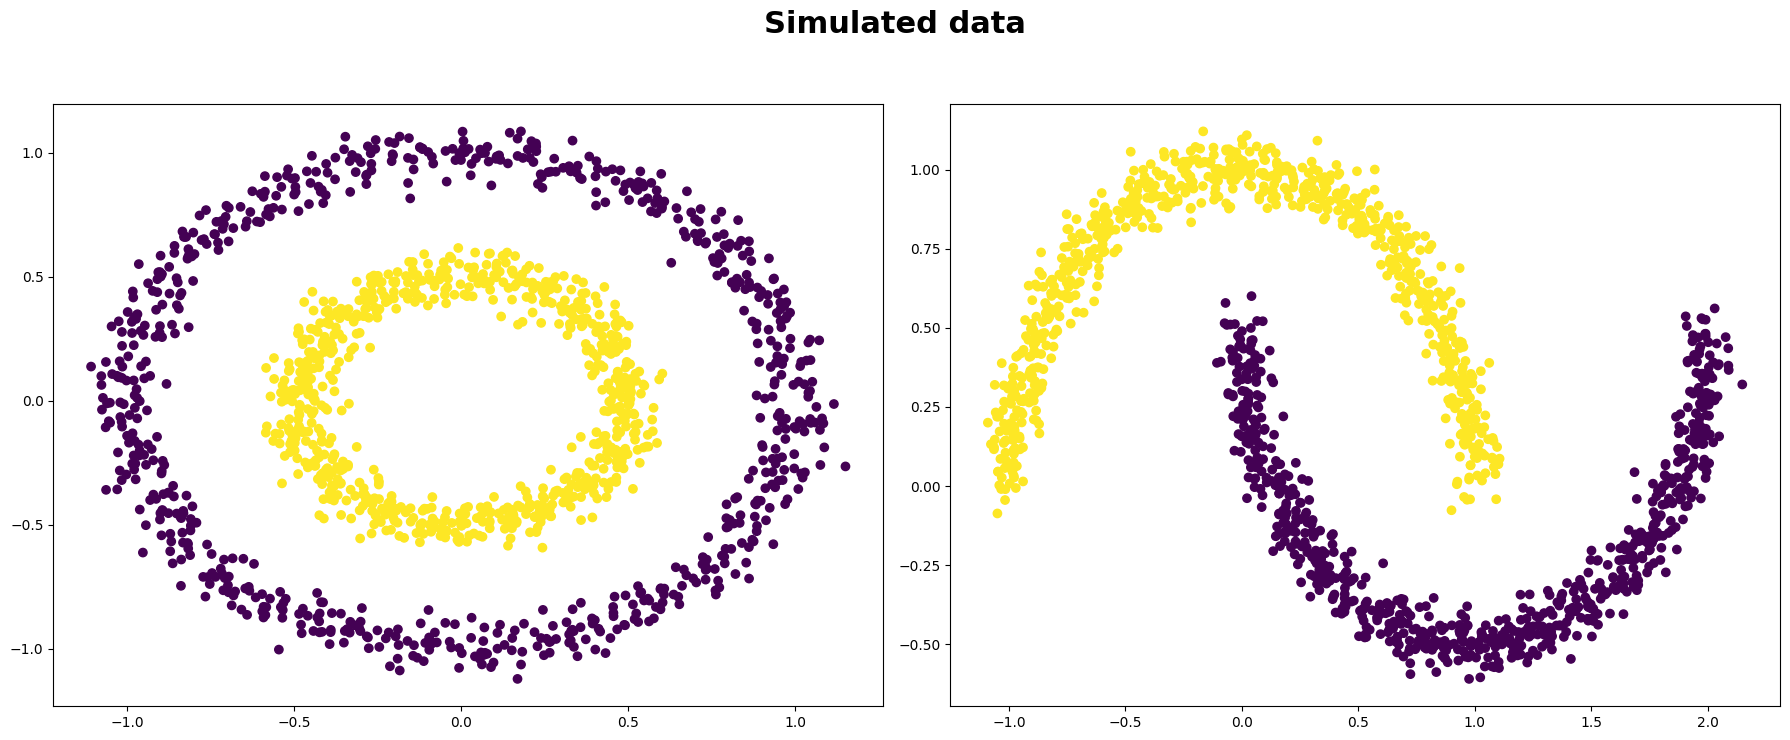

In [ ]:
from sklearn.cluster import KMeans, SpectralClustering

# Cricles
X1 = make_circles(factor=0.5, noise=0.05, n_samples=1500)

# Moons
X2 = make_moons(n_samples=1500, noise=0.05)

fig, ax = plt.subplots(1, 2)
for i, X in enumerate([X1, X2]):
    fig.set_size_inches(18, 7)
    sp = SpectralClustering(n_clusters=2, affinity='nearest_neighbors')
    sp.fit(X[0])
    labels = sp.labels_
    ax[i].scatter(X[0][:, 0], X[0][:, 1], c=labels)
plt.suptitle('Simulated data', y=1.05, fontsize=22, fontweight='semibold')
plt.tight_layout();

# Digits clustering

In [ ]:
import numpy as np

from sklearn.datasets import load_digits

X, y = load_digits(return_X_y=True)
(n_samples, n_features), n_digits = X.shape, np.unique(y).size

print(f"# digits: {n_digits}; # samples: {n_samples}; # features {n_features}")

# digits: 10; # samples: 1797; # features 64


In [ ]:
digits_indicies_examples = {}
for idx, digit in enumerate(y):
  # print(digit)
  if digit not in digits_indicies_examples:
    digits_indicies_examples[digit] = X[idx].tolist()

In [ ]:
digits_indicies_examples.keys()

dict_keys([np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9)])

In [ ]:
init_centroids = list(digits_indicies_examples.values())


In [ ]:
kmeans = KMeans(n_clusters = 10,
                init = init_centroids,
                random_state = 42)

In [ ]:
y_pred = kmeans.fit_predict(X)

In [ ]:
y[547]

np.int64(9)

In [ ]:
y_pred[547]

np.int32(8)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Note: K-Means is an unsupervised algorithm, so the cluster labels (y_pred) are arbitrary.
# To calculate accuracy, we need to map the predicted cluster labels to the true digit labels.
# A common approach is to find the best mapping using a greedy approach or linear assignment.
# For simplicity, here we'll assume an arbitrary mapping or rely on a more robust evaluation metric like adjusted_rand_score or normalized_mutual_info_score
# However, if the intent is to see how well the clusters align with known labels, we can use these metrics.

# For this demonstration, let's just show a simple (though not necessarily accurate) classification report
# by attempting a mapping or by directly comparing which is often incorrect due to label permutation.
# A more proper evaluation for K-Means with known labels would involve Adjusted Rand Index or Normalized Mutual Information.

# Let's perform a simple (and often incorrect for direct accuracy) check first, as requested:
# Note: This accuracy will likely be low because KMeans assigns arbitrary labels (0, 1, 2, etc.) to clusters,
# and these don't necessarily correspond directly to the true digit labels (0, 1, 2, etc.).
# A more appropriate metric for clustering evaluation with ground truth would be adjusted_rand_score or normalized_mutual_info_score.

print("Accuracy Score (direct comparison, likely incorrect due to label permutation):", accuracy_score(y, y_pred))
print("\nClassification Report (direct comparison, labels may not align):")
print(classification_report(y, y_pred))

Accuracy Score (direct comparison, likely incorrect due to label permutation): 0.5381190873678353

Classification Report (direct comparison, labels may not align):
              precision    recall  f1-score   support

           0       0.99      0.99      0.99       178
           1       0.83      0.55      0.66       182
           2       0.02      0.01      0.02       177
           3       0.01      0.01      0.01       183
           4       0.99      0.89      0.94       181
           5       0.11      0.21      0.14       182
           6       0.97      0.97      0.97       181
           7       0.85      0.95      0.90       179
           8       0.82      0.78      0.80       174
           9       0.03      0.03      0.03       180

    accuracy                           0.54      1797
   macro avg       0.56      0.54      0.55      1797
weighted avg       0.56      0.54      0.54      1797

